In [3]:
# Import series of helper function for the notebook
from Helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Get a text dataset

The dataset we're going to be using is Kaggle's introduction to NLP dataset (text samples of Tweets labelled as disaster or not disaster)

In [4]:
import pandas as pd

train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

train_data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
train_data['text'][0]

'Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all'

In [6]:
# Shuffle training dataframe
train_data_shuffled = train_data.sample(frac=1, random_state=42)
train_data_shuffled

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0
...,...,...,...,...,...
5226,7470,obliteration,Merica!,@Eganator2000 There aren't many Obliteration s...,0
5390,7691,panic,NaN,just had a panic attack bc I don't have enough...,0
860,1242,blood,NaN,Omron HEM-712C Automatic Blood Pressure Monito...,0
7603,10862,NaN,NaN,Officials say a quarantine is in place at an A...,1


In [7]:
# Test data
test_data.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [8]:
# Count of samples
train_data.target.value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [9]:
# Let's visualize some random training examples
import random 
random_index = random.randint(0, len(train_data)-5) # Create random indexes
for row in train_data_shuffled[["text", "target"]][random_index:random_index+5].itertuples():
    _, text, target = row
    print(f"Target: {target}", "(real disaster)" if target > 0 else "(not real disaster)")
    print(f"Text:\n{text}\n")
    print("---\n")

Target: 1 (real disaster)
Text:
Refugio oil spill may have been costlier bigger than projected (LA Times) http://t.co/TCSoLvwhXq

---

Target: 0 (not real disaster)
Text:
@kirstiealley @_AnimalAdvocate Or pay it for a photo safari no weapons allowed. Otherwise=they just like to kill something.

---

Target: 0 (not real disaster)
Text:
WWI WWII JAPANESE ARMY NAVY MILITARY JAPAN LEATHER WATCH WAR MIDO WW1 2 - Full read by eBay http://t.co/QUmcE7W2tY http://t.co/KTKG2sDhHl

---

Target: 0 (not real disaster)
Text:
@SterlingKnight  Who had a car crashsterling!Who was driving in the carMel or JoeySterling Knight???????

---

Target: 0 (not real disaster)
Text:
I think I just blew up @HopeInHearts notifications. Go check her out she's so encouraging to me ???? love her ??

---



### Split data into training and validation sets
Since the test set has no labels and we need a way to evaluate our trained models, we'll split off some of the trianing data and create validation set.

In [10]:
from sklearn.model_selection import train_test_split

train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_data_shuffled["text"].to_numpy(),
                                                                            train_data_shuffled["target"].to_numpy(),
                                                                            test_size=0.1,
                                                                            random_state=42)

In [11]:
# checking the length
len(train_sentences), len(train_labels), len(val_sentences), len(val_labels)

(6851, 6851, 762, 762)

In [12]:
# first 10 training sentences and their labels
train_sentences[:10], train_labels

(array(['@mogacola @zamtriossu i screamed after hitting tweet',
        'Imagine getting flattened by Kurt Zouma',
        '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
        "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
        'Somehow find you and I collide http://t.co/Ee8RpOahPk',
        '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
        'destroy the free fandom honestly',
        'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
        '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
        'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
       dtype=object),
 array([0,

## Converting text into numbers

There are two main techniques to convert text into numbers:

1. Text tokenization
2. Text embeddings

### Text tokenization

In [13]:
import tensorflow as tf 
from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens=None, # how many words in the vocabulary (all of the different words in text)
                                    standardize="lower_and_strip_punctuation",
                                    split="whitespace",
                                    ngrams=None,
                                    output_mode="int",
                                    output_sequence_length=None)

In [14]:
# Find average number of tokens (words) in training tweets
round(sum([len(i.split()) for i in train_sentences])/len(train_sentences))

15

In [15]:
# Setup text vectorization variables
max_vocab_length = 10000 # max number of words to have in our vocabulary
max_length = 15

text_vectorizer = TextVectorization(max_tokens=max_vocab_length,
                                    output_mode="int",
                                    output_sequence_length=max_length)

In [16]:
# Fit the text vectorizer to the training text
text_vectorizer.adapt(train_sentences)

In [17]:
# Create a sample sentence and tokenize it 
sample_sentence = "There's a flood in my street!"
text_vectorizer([sample_sentence])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[264,   3, 232,   4,  13, 698,   0,   0,   0,   0,   0,   0,   0,
          0,   0]], dtype=int64)>

In [18]:
# Choose a random sentence from the training dataset and tokenize it
random_sentence = random.choice(train_sentences)
print(f"Original text:\n {random_sentence}\
    \n\nVectorized version:")
text_vectorizer([random_sentence])

Original text:
 @c_pinto001 I see people are panicking about Orpik all over again.    

Vectorized version:


<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[  1,   8,  99,  57,  22, 535,  54,   1,  44,  60, 282,   0,   0,
          0,   0]], dtype=int64)>

In [19]:
# Get the unique words in the vocabulary
words_in_vocab = text_vectorizer.get_vocabulary() # Get all of the unique words in our training data
top_5_words = words_in_vocab[:5] # get the most common words
bottom_5_words = words_in_vocab[-5:] # get the least common words
print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"5 most common words: {top_5_words}")
print(f"5 least common words: {bottom_5_words}")

Number of words in vocab: 10000
5 most common words: ['', '[UNK]', 'the', 'a', 'in']
5 least common words: ['pages', 'paeds', 'pads', 'padres', 'paddytomlinson1']


## Creating an Embedding using an Embedding Layer

The parameters we care most about for our embedding layer:
* `input_dim` = the size of our vocabulary
* `output_dim` = the size of the output embedding vector, for example, a value of 100 would mean each token gets represented by a vector 100 long
* `input_length` = length of the sequences being passed to the embedding layer

In [20]:
from tensorflow.keras import layers

embedding = layers.Embedding(input_dim=max_vocab_length, # set input shape
                             output_dim=128,
                             input_length=max_length # how long is each input
                             )
embedding

In [21]:
# Get a random sentence from the training set
random_sentence = random.choice(train_sentences)
print(f"Original text:\n {random_sentence}\
    \n\nEmbedded version:")

# Embed the random sentence (turn it into dense vectors of fixed size)
sample_embed = embedding(text_vectorizer([random_sentence]))
sample_embed

Original text:
 Aircraft debris found on island is from MH370 Malaysia confirms http://t.co/X3RccHKagO    

Embedded version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[ 0.02818022, -0.00295824,  0.04980543, ...,  0.02774545,
          0.00017432,  0.0172751 ],
        [-0.02776816,  0.03852346, -0.00685791, ...,  0.04834583,
         -0.02677541,  0.04926496],
        [-0.00667689, -0.04431751, -0.03990611, ..., -0.01465088,
         -0.00736745,  0.04888791],
        ...,
        [ 0.04622504,  0.039783  , -0.00141602, ..., -0.03091962,
          0.04156879, -0.01728859],
        [ 0.04622504,  0.039783  , -0.00141602, ..., -0.03091962,
          0.04156879, -0.01728859],
        [ 0.04622504,  0.039783  , -0.00141602, ..., -0.03091962,
          0.04156879, -0.01728859]]], dtype=float32)>

In [22]:
# Check out a single token's embdedding
sample_embed[0][0], sample_embed[0][0].shape, random_sentence

(<tf.Tensor: shape=(128,), dtype=float32, numpy=
 array([ 0.02818022, -0.00295824,  0.04980543, -0.02856206,  0.03339585,
        -0.02266866,  0.04299762,  0.03497031,  0.03373182, -0.02614003,
         0.01921228,  0.00785973,  0.03574345,  0.03540415, -0.04332597,
        -0.00822502,  0.04653067,  0.04646483, -0.02038401,  0.01713676,
         0.04592273, -0.02787094,  0.03868613, -0.03558857, -0.01121659,
        -0.04760943,  0.00474016, -0.00401459, -0.03475865,  0.04449084,
         0.01356932, -0.01662952,  0.01276324,  0.00047245, -0.04363939,
         0.00295278, -0.02950977, -0.02382007, -0.02767453, -0.0364885 ,
         0.01230709, -0.04832963, -0.0263052 ,  0.04405097,  0.03121914,
        -0.00716758,  0.00948179, -0.01928766,  0.02720051,  0.04547406,
         0.01745326, -0.02519049,  0.02206531,  0.04266203, -0.000763  ,
         0.01952808, -0.00740786, -0.02300615,  0.01849911,  0.00295977,
        -0.03871769, -0.04502727,  0.03772489, -0.03273918,  0.02639939,
  

## Modelling a text dataset (running a series of experiments)

Now we've a got way to turn our text sequences into numbers, it's time to start building a series of modelling experiments.

We'll start with a baseline and move on from there

* Model 0: Naive Bayes (baseline).
* Model 1: Feed-Forward neural network (dense model)
* Model 2: LSTM model (RNN)
* Model 3: GRU model (RNN)\
* Model 4: Bidirectional-LSTM model (RNN)
* Model 5: 1D Convolutional Neural Network (CNN)
* Model 6: TensorFlow Hub pretrained feature extractor (using transfer learning for NLP)
* Model 7: Same as model 6 with 10% of training data.

### Model 0: Getting a baseline

As with all machine learning modelling experiments, it's important to create as baseline model so you have got a benchmark for future experiments to build upon.

To create our baseline, we'll use sklearn's multinomial naive bayes using the TF-IDF formula to convert our words to numbers.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create tokenization and modelling pipeline
model_0 = Pipeline([
    ("tfidf", TfidfVectorizer()), # convert words to numbers 
    ("clf", MultinomialNB()) # model the text
])

# Fit the pipeline to the training data
model_0.fit(train_sentences, train_labels)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [24]:
# Evaluate our baseline model
baseline_score = model_0.score(val_sentences, val_labels)
print(f"Our baseline model achieves an accuracy of: {baseline_score*100:.2f}%")

Our baseline model achieves an accuracy of: 79.27%


In [25]:
# Make predictions 
baseline_preds = model_0.predict(val_sentences)
baseline_preds[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
      dtype=int64)

### Creating an evaluation function for our model experiments

In [26]:
# Function to evaluate: accuracy, precision, recall and f1-score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):
    """
    Calculates model accuracy, precision, recall and f1 score of a binary classification model.

    """
    # Calculate model accuracy 
    model_accuracy = accuracy_score(y_true, y_pred) * 100
    # Calculate model precision , recall and f1-score using "weighted" average
    model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    model_results = {"accuracy": model_accuracy,
                     "precision": model_precision,
                     "recall": model_recall,
                     "f1": model_f1}
    return model_results    

In [27]:
# Get baseline result
baseline_results = calculate_results(y_true=val_labels,
                                     y_pred=baseline_preds)
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

### Model 1: A simple dense model

In [28]:
# BUild model with the Funcitonal API
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype=tf.string) # inputs are 1-dimensional strings
x = text_vectorizer(inputs) # turn the input text into numbers
x = embedding(x) # embedding of the numberized inputs
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x) # output layers 
model_1 = tf.keras.Model(inputs, outputs, name="model_1_dense")

In [29]:
model_1.summary()

Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1280129 (4.88 MB)
Trainable params: 128

In [30]:
# Compile model
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [31]:
val_sentences.shape, val_labels.shape

((762,), (762,))

In [32]:
# fit the model
model_1_history = model_1.fit(x=train_sentences,
                              y=train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5

215/215 [==============================] - 4s 15ms/step - loss: 0.6121 - accuracy: 0.6838 - val_loss: 0.5357 - val_accuracy: 0.7533
Epoch 2/5
215/215 [==============================] - 3s 14ms/step - loss: 0.4417 - accuracy: 0.8170 - val_loss: 0.4689 - val_accuracy: 0.7861
Epoch 3/5
215/215 [==============================] - 3s 15ms/step - loss: 0.3466 - accuracy: 0.8605 - val_loss: 0.4560 - val_accuracy: 0.7913
Epoch 4/5
215/215 [==============================] - 3s 14ms/step - loss: 0.2845 - accuracy: 0.8914 - val_loss: 0.4623 - val_accuracy: 0.7913
Epoch 5/5
215/215 [==============================] - 3s 16ms/step - loss: 0.2370 - accuracy: 0.9118 - val_loss: 0.4825 - val_accuracy: 0.7835


In [33]:
# Check the results
model_1.evaluate(val_sentences, val_labels)

24/24 [==============================] - 0s 2ms/step - loss: 0.4825 - accuracy: 0.7835


[0.48245924711227417, 0.7834645509719849]

In [34]:
# Make some predictions and evalutate those
model_1_pred_probs = model_1.predict(val_sentences)
model_1_pred_probs.shape

24/24 [==============================] - 0s 1ms/step


(762, 1)

In [35]:
model_1_pred_probs[0]

array([0.35751933], dtype=float32)

In [36]:
# Convert model prediciton probabilities  to label format
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs))
model_1_preds[:20]

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1.], dtype=float32)>

In [37]:
# Calculate our model_1 results
model_1_results = calculate_results(y_true=val_labels,
                                    y_pred=model_1_preds)
model_1_results

{'accuracy': 78.34645669291339,
 'precision': 0.7884290282979772,
 'recall': 0.7834645669291339,
 'f1': 0.7803444000779524}

## Visualizing learned mebeddings

In [38]:
# Get the vocabulary from the text vectorization layer
words_in_vocab = text_vectorizer.get_vocabulary()
len(words_in_vocab), words_in_vocab[:10]

(10000, ['', '[UNK]', 'the', 'a', 'in', 'to', 'of', 'and', 'i', 'is'])

In [39]:
# model 1 summary
model_1.summary()

Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1280129 (4.88 MB)
Trainable params: 128

In [40]:
# Get tghe weight matrix of embedding layer
# (these are the numerical representations of each token in our training, which have been learned for ~5 epochs)
embed_weights = model_1.get_layer("embedding").get_weights()[0]
embed_weights.shape

(10000, 128)

In [41]:
# Create mebedding files (we got this from TensorFlow's word embedding documnetation)
import io
out_v = io.open('vectors.tsv', 'w', encoding='utf-8')
out_m = io.open('metadata.tsv', 'w', encoding='utf-8')

for index, word in enumerate(words_in_vocab):
    if index == 0:
        continue # Skip 0, it's padding.
    vec = embed_weights[index]
    out_v.write('\t'.join([str(x) for x in vec]) + "\n")
    out_m.write(word + "\n")
out_v.close()
out_m.close()

## Recurrent Neural Networks (RNN's)

RNN's are useful for sequential data.

The premise of a recurrent neural network is to use the representation of a previous input to aid the representation of a later input.


### Model 2: LSTM

Our structure of an RNN typically looks like this:

```
Input (txt) -> Tokenize -> Embedding -> Layers (RNNs/Dense) -> Output (label probability)
```

In [42]:
# Create an LSTM model
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype="string")
x = text_vectorizer(inputs)
x = embedding(x)
# print(x.shape)
x = layers.LSTM(64, return_sequences=True)(x) # when you're stacking RNN cells together , you need to set return_sequences=True
# print(x.shape)
x = layers.LSTM(64)(x)
# print(x.shape)
# x = layers.Dense(64, activation="relu")(x)
# print(x.shape)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_2 = tf.keras.Model(inputs, outputs, name="model_2_LSTM")

In [43]:
# Get a summary()
model_2.summary()

Model: "model_2_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 lstm (LSTM)                 (None, 15, 64)            49408     
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                      

In [44]:
# Compile the model
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [45]:
# Fit the model
model_2.history = model_2.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 [==============================] - 10s 28ms/step - loss: 0.2175 - accuracy: 0.9212 - val_loss: 0.5946 - val_accuracy: 0.7769
Epoch 2/5
215/215 [==============================] - 5s 22ms/step - loss: 0.1596 - accuracy: 0.9400 - val_loss: 0.6140 - val_accuracy: 0.7795
Epoch 3/5
215/215 [==============================] - 5s 23ms/step - loss: 0.1280 - accuracy: 0.9515 - val_loss: 0.7534 - val_accuracy: 0.7822
Epoch 4/5
215/215 [==============================] - 5s 22ms/step - loss: 0.1069 - accuracy: 0.9602 - val_loss: 0.7960 - val_accuracy: 0.7835
Epoch 5/5
215/215 [==============================] - 5s 23ms/step - loss: 0.0845 - accuracy: 0.9651 - val_loss: 0.9595 - val_accuracy: 0.7730


In [46]:
# Make predictions with LSTM model
model_2_pred_probs = model_2.predict(val_sentences)
model_2_pred_probs[:10]

24/24 [==============================] - 1s 6ms/step


array([[3.8936259e-03],
       [6.8136096e-01],
       [9.9991602e-01],
       [9.1032237e-02],
       [2.1750771e-04],
       [9.9967110e-01],
       [8.7016559e-01],
       [9.9992555e-01],
       [9.9988371e-01],
       [4.2892972e-01]], dtype=float32)

In [47]:
# Convert model 2 pred probs to labels
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [48]:
# Calculate model 2 results
model_2_results = calculate_results(y_true=val_labels,
                                    y_pred=model_2_preds)
model_2_results

{'accuracy': 77.29658792650919,
 'precision': 0.7750482481613202,
 'recall': 0.7729658792650919,
 'f1': 0.7707112186521387}

In [49]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

### Model 3: GRU

Another popular and effective RNN component is the GRU or gated recurrent unit.
The GRU cell has similar features to an LSTM cell but but has less parameters.

In [50]:
# Buld an RNN using the GRU cell
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = layers.GRU(64)(x)
# x = layers.GRU(64, return_sequences=True)(x)
# x = layers.LSTM(64, return_sequences=True)(x)
# x = layers.GRU(64, return_sequences=True)(x)
# x = layers.Dense(64, activation="relu")(x)
# x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_3 = tf.keras.Model(inputs, outputs, name="model_3_GRU")

In [51]:
model_3.summary()

Model: "model_3_GRU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 gru (GRU)                   (None, 64)                37248     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1317313 (5.03 MB)
Trainable params: 1317313 (5.03 MB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [52]:
# Compile the model
model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [53]:
# Fit the model
model_3_history = model_3.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 [==============================] - 7s 22ms/step - loss: 0.1522 - accuracy: 0.9434 - val_loss: 0.7046 - val_accuracy: 0.7730
Epoch 2/5
215/215 [==============================] - 4s 19ms/step - loss: 0.0865 - accuracy: 0.9696 - val_loss: 0.8057 - val_accuracy: 0.7743
Epoch 3/5
215/215 [==============================] - 4s 18ms/step - loss: 0.0704 - accuracy: 0.9740 - val_loss: 1.0331 - val_accuracy: 0.7703
Epoch 4/5
215/215 [==============================] - 4s 18ms/step - loss: 0.0583 - accuracy: 0.9759 - val_loss: 1.2450 - val_accuracy: 0.7743
Epoch 5/5
215/215 [==============================] - 4s 19ms/step - loss: 0.0538 - accuracy: 0.9755 - val_loss: 1.1458 - val_accuracy: 0.7795


In [54]:
# Make some predictions with our GRU model
model_3_pred_probs = model_3.predict(val_sentences)
model_3_pred_probs[:10]

24/24 [==============================] - 1s 3ms/step


array([[1.18425693e-02],
       [7.98646748e-01],
       [9.99920070e-01],
       [1.33087695e-01],
       [1.02791426e-04],
       [9.99860108e-01],
       [9.87294674e-01],
       [9.99949217e-01],
       [9.99917626e-01],
       [9.81136084e-01]], dtype=float32)

In [55]:
# Convert model 3 pred probs to labels
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [56]:
# calculate model 3 results
model_3_results = calculate_results(y_true=val_labels,
                                    y_pred=model_3_preds)
model_3_results

{'accuracy': 77.95275590551181,
 'precision': 0.7795261140776376,
 'recall': 0.7795275590551181,
 'f1': 0.7786058734339147}

### Model 4: Bidirectional RNN
Normal RNN's go from left to right (just like you'd read an English sentence) however, a bidirectional RNN goes left to right also.

In [57]:
# Build a bidirectional RNN in TensorFlow
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype="string")
x = text_vectorizer(inputs)
x = embedding(x)
# x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_4 = tf.keras.Model(inputs, outputs, name="model_4_bidirectional")

In [58]:
# Get a summary
model_4.summary()

Model: "model_4_bidirectional"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1378945 (5.26 MB)
Trainable par

In [59]:
# Compile model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [60]:
# Fit the model
model_4_hisrtory = model_4.fit(train_sentences,
                               train_labels,
                               epochs=5,
                               validation_data=(val_sentences, val_labels)
                               )

Epoch 1/5
215/215 [==============================] - 9s 24ms/step - loss: 0.1056 - accuracy: 0.9689 - val_loss: 1.0343 - val_accuracy: 0.7782
Epoch 2/5
215/215 [==============================] - 4s 18ms/step - loss: 0.0494 - accuracy: 0.9772 - val_loss: 1.1892 - val_accuracy: 0.7717
Epoch 3/5
215/215 [==============================] - 4s 18ms/step - loss: 0.0465 - accuracy: 0.9797 - val_loss: 1.2146 - val_accuracy: 0.7638
Epoch 4/5
215/215 [==============================] - 4s 20ms/step - loss: 0.0454 - accuracy: 0.9785 - val_loss: 1.3934 - val_accuracy: 0.7703
Epoch 5/5
215/215 [==============================] - 4s 20ms/step - loss: 0.0431 - accuracy: 0.9781 - val_loss: 1.1918 - val_accuracy: 0.7703


In [61]:
# Make predicitons with our bidirectional model
model_4_pred_probs = model_4.predict(val_sentences) 
model_4_pred_probs[:10]

24/24 [==============================] - 1s 4ms/step


array([[1.5611835e-03],
       [5.4387581e-01],
       [9.9978727e-01],
       [3.3287641e-01],
       [2.7869513e-05],
       [9.9846196e-01],
       [7.8381079e-01],
       [9.9993384e-01],
       [9.9981499e-01],
       [9.4680715e-01]], dtype=float32)

In [62]:
# Convert pred probs to pred labels
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))
model_4_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [63]:
# Calculate the results of our bidirectional model
model_4_results = calculate_results(y_true=val_labels,
                                    y_pred=model_4_preds)
model_4_results

{'accuracy': 77.03412073490814,
 'precision': 0.7720778836459699,
 'recall': 0.7703412073490814,
 'f1': 0.7681933440908485}

### Convolution Neural Networks for Text (and other types of sequences)

We've used CNNs for images are typically 2D (height x width)... however, our text data is 1D.
Previously we've Conv2D for our image data but now we're going to use Conv1D.
The typical structure of a COnv1D model for sequences (in our case text)

```
Inputs (text) -> Tokenization -> Embedding -> Layer(s) (typically Conv1D + pooling) -> Outputs (class probabilities)
```

### Model 5: Conv1D

In [64]:
# Test out our embedding layer, Con1D layer and max pooling 
from tensorflow.keras import layers
embedding_test = embedding(text_vectorizer(["this is a test sentence"]))
conv_1d = layers.Conv1D(filters=32,
                        kernel_size=5,
                        strides=1, # default  
                        activation="relu",
                        padding="same")
conv_1d_output = conv_1d(embedding_test) # pass test embedding through conv1d layer
max_pool = layers.GlobalMaxPool1D()
max_pool_output = max_pool(conv_1d_output) 
embedding_test.shape, conv_1d_output.shape, max_pool_output.shape

(TensorShape([1, 15, 128]), TensorShape([1, 15, 32]), TensorShape([1, 32]))

In [65]:
# Create 1-dimensional convolutional layer to model sequence
from tensorflow.keras import layers
inputs = layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = layers.Conv1D(filters=64, kernel_size=5, strides=1, activation="relu", padding="valid")(x)
x = layers.GlobalMaxPool1D()(x)
# x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model_5 = tf.keras.Model(inputs, outputs, name="model_5_Conv1D")

# Compile Conv1D
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Get a summary of our Conv1D model
model_5.summary()

Model: "model_5_Conv1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 conv1d_1 (Conv1D)           (None, 11, 64)            41024     
                                                                 
 global_max_pooling1d_1 (Gl  (None, 64)                0         
 obalMaxPooling1D)                                               
                                                                 
 dense_4 (Dense)             (None, 1)              

In [66]:
#  Fit the model
model_5_history = model_5.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

Epoch 1/5
215/215 [==============================] - 4s 16ms/step - loss: 0.1189 - accuracy: 0.9635 - val_loss: 0.9389 - val_accuracy: 0.7703
Epoch 2/5
215/215 [==============================] - 3s 15ms/step - loss: 0.0742 - accuracy: 0.9712 - val_loss: 1.0247 - val_accuracy: 0.7730
Epoch 3/5
215/215 [==============================] - 3s 16ms/step - loss: 0.0604 - accuracy: 0.9769 - val_loss: 1.1176 - val_accuracy: 0.7677
Epoch 4/5
215/215 [==============================] - 3s 15ms/step - loss: 0.0537 - accuracy: 0.9787 - val_loss: 1.1487 - val_accuracy: 0.7598
Epoch 5/5
215/215 [==============================] - 3s 14ms/step - loss: 0.0511 - accuracy: 0.9794 - val_loss: 1.2152 - val_accuracy: 0.7625


In [67]:
# Make some predictions with our Conv1D model
model_5_pred_probs = model_5.predict(val_sentences)
model_5_pred_probs[:10]

24/24 [==============================] - 0s 2ms/step


array([[2.8282243e-01],
       [4.4942129e-01],
       [9.9997288e-01],
       [4.8874460e-02],
       [7.1962558e-07],
       [9.9363828e-01],
       [8.9580125e-01],
       [9.9998838e-01],
       [9.9999911e-01],
       [8.9445943e-01]], dtype=float32)

In [68]:
# Convert model 5 pred probs to labels
model_5_preds = tf.squeeze(tf.round(model_5_pred_probs))
model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 0., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [69]:
# Evaluate model 5 predicitons
model_5_results = calculate_results(y_true=val_labels,
                                    y_pred=model_5_preds)
model_5_results

{'accuracy': 76.24671916010499,
 'precision': 0.7625326572242482,
 'recall': 0.7624671916010499,
 'f1': 0.7612168110136286}

In [70]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

## Model 6: TensorFlow Hub Pretrained sentence encoder

Now we've built a few of our models, let's try and use transfer learning for NLP, specifically using TensorFlow Hub's universal sentence encoder

In [72]:
import tensorflow_hub as hub

embed = hub.load("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2")
embed_samples = embed([sample_sentence,
                       "When you can the universal sentence encoder on a sentence, it turns it into numbers."])


ValueError: Trying to load a model of incompatible/unknown type. 'C:\Users\Priyesh\AppData\Local\Temp\tfhub_modules\01b27d6b983e268d7ade6823c2452458cf1a12c4' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.

In [73]:
embed_samples[0].shape

NameError: name 'embed_samples' is not defined

In [74]:
# Create a keras layer using the USE pretrained layer from tensorflow hub
sentence_encoder_layer = hub.KerasLayer("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2", 
                                        input_shape=[],
                                        dtype=tf.string,
                                        trainable=False,
                                        name="USE")


ValueError: Trying to load a model of incompatible/unknown type. 'C:\Users\Priyesh\AppData\Local\Temp\tfhub_modules\01b27d6b983e268d7ade6823c2452458cf1a12c4' contains neither 'saved_model.pb' nor 'saved_model.pbtxt'.

In [75]:
# Create model using the Sequential API
model_6 = tf.keras.Sequential([
    sentence_encoder_layer,
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="model_6_USE")

# Compile 
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

model_6.summary()

NameError: name 'sentence_encoder_layer' is not defined

In [76]:
# Train a classifier on top of USE pretrained embeddings
model_6_history = model_6.fit(train_sentences,
                              train_labels,
                              epochs=5,
                              validation_data=(val_sentences, val_labels),
                              )

NameError: name 'model_6' is not defined

In [77]:
# make predictions with USE TF Hub model
model_6_pred_probs = model_6.predict(val_sentences)
model_6_pred_probs[:10]

NameError: name 'model_6' is not defined

In [78]:
# Convert prediction probabilities to labels 
model_6_preds = tf.squeeze(tf.round(model_6_pred_probs))
model_6_preds[:10]

NameError: name 'model_6_pred_probs' is not defined

In [79]:
# Calculate model 6 performance metrics
model_6_results = calculate_results(y_true=val_labels,
                                    y_pred=model_6_preds)
model_6_results

NameError: name 'model_6_preds' is not defined

In [80]:
len(train_data_shuffled)

7613

## Model 7: TF Hub Pretrained USE but with 10% of training data
Transfer learning really helps when you don't have a large dataset.
To see how our model performs on a smaller dataset, let's replicate model_6 except we'll train it on 10% of the data.

In [81]:
# Create subsets of 10% of the training data
train_10_percent = train_data_shuffled[["text", "target"]].sample(frac=0.1, random_state=42)
train_sentences_10_percent = train_10_percent["text"].to_list()
train_labels_10_percent = train_10_percent["target"].to_list()
len(train_sentences_10_percent), len(train_labels_10_percent)

(761, 761)

In [82]:
# Check the number of targets in our subset of data
train_10_percent["target"].value_counts()

target
0    413
1    348
Name: count, dtype: int64

In [83]:
train_data_shuffled["target"].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

In [84]:
# Let's built a model the same as model_6
model_7 = tf.keras.models.clone_model(model_6)

# Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Get a summary 
model_7.summary()

NameError: name 'model_6' is not defined

In [85]:
# Fit the model to the 10% training data subsets
model_7_history = model_7.fit(train_sentences_10_percent,
                              train_labels_10_percent,
                              epochs=5,
                              validation_data=(val_sentences, val_labels))

NameError: name 'model_7' is not defined

In [86]:
# Make precitions with the model trained on 10% of the data
model_7_pred_probs = model_7.predict(val_sentences)
model_7_pred_probs[:10]

NameError: name 'model_7' is not defined

In [87]:
# Turn pred probs into labels
model_7_preds = tf.squeeze(tf.round(model_7_pred_probs))
model_7_preds[:10]

NameError: name 'model_7_pred_probs' is not defined

In [88]:
# Evaluate model_7 predictions
model_7_results = calculate_results(y_true=val_labels,
                                    y_pred=model_7_preds)
model_7_results

NameError: name 'model_7_preds' is not defined

In [89]:
model_6_results

NameError: name 'model_6_results' is not defined

In [90]:
# Making a better dataset split (no data leakage)
train_10_percent_split = int(0.1 * len(train_sentences))
train_sentences_10_percent = train_sentences[:train_10_percent_split]
train_labels_10_percent = train_labels[:train_10_percent_split]
len(train_labels_10_percent)

685

**Note:** Be very careful when creating training/val/test splits that you don't leak data across the datasets, otherwise your model evaluation metrics will be wrong. If something looks too good to be true (a model trained on 10% of data outperforming the same model trained on 100% of data) trust your gut and go back through to find where the error may lie.

In [91]:
import numpy as np
pd.Series(np.array(train_labels_10_percent)).value_counts()

0    406
1    279
Name: count, dtype: int64

## Comparing the performance of each of our models

In [92]:
# Combine model results into a DataFrame
all_model_results = pd.DataFrame({"baseline": baseline_results,
                                  "1_simple_dense": model_1_results,
                                  "2_lstm": model_2_results,
                                  "3_gru": model_3_results,
                                  "4_bidirectional": model_4_results,
                                  "5_conv1d": model_5_results,
                                  "6_tf_hub_use_encoder": model_6_results,
                                  "7_tf_hub_use_encoder_10_percent": model_7_results})
all_model_results = all_model_results.transpose()
all_model_results

NameError: name 'model_6_results' is not defined

In [93]:
# Reduce the accuracy to the same scale as other metrics
all_model_results["accuracy"] = all_model_results["accuracy"] / 100
all_model_results

NameError: name 'all_model_results' is not defined

In [94]:
# Plot and compare all of the model
all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));

NameError: name 'all_model_results' is not defined

## Saving and loading a trained model

In [95]:
# Save TF Hub sentence encoder model to HDF5 format
model_6.save("model_6.h5")

NameError: name 'model_6' is not defined

In [96]:
# Load model with custom Hub layer (required HDF5 format)
import tensorflow_hub as hub
loaded_model_6 = tf.keras.models.load_model("model_6.h5",
                                            custom_objects={"KerasLayer": hub.KerasLayer})

OSError: No file or directory found at model_6.h5

In [97]:
# how does our loaded model perform?
loaded_model_6.evaluate(val_sentences, val_labels)

NameError: name 'loaded_model_6' is not defined

In [98]:
# Save TF hub sentence encoder model to SavedModel format (default)
model_6.save("model_6_saved_model_format")

NameError: name 'model_6' is not defined

In [99]:
# Load in a model from the saved model format
import tensorflow as tf
loaded_model_6_savedModel_format = tf.keras.models.load_model("model_6_saved_model_format")

In [100]:
loaded_model_6_savedModel_format.evaluate(val_sentences, val_labels)

24/24 [==============================] - 1s 16ms/step - loss: 0.4290 - accuracy: 0.8163


[0.42901867628097534, 0.8162729740142822]

### Finding the most wrong examples

* If our best model still isn't perfect, what examples is it getting wrong?
* And of these wrong examples which ones is it getting most wrong (those will prediction probabilities closest to the opposite class)

For example if a sample should have a label of 0 but our model predicts a prediction probability of 0.999 (really close to 1) and vice versa.

In [101]:
# Importing previously trained model from Google Storage
model_6_pretrained = tf.keras.models.load_model("model_6_saved_model_format")
model_6_pretrained.evaluate(val_sentences, val_labels)

24/24 [==============================] - 1s 13ms/step - loss: 0.4290 - accuracy: 0.8163


[0.42901867628097534, 0.8162729740142822]

In [102]:
# Make predictions with the loaded model from GS
model_6_pretrained_pred_probs = model_6_pretrained.predict(val_sentences)
model_6_pretrained_preds = tf.squeeze(tf.round(model_6_pretrained_pred_probs))
model_6_pretrained_preds[:10] # these should be in label format

24/24 [==============================] - 1s 7ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 1., 1., 1., 1., 1., 0.], dtype=float32)>

In [103]:
# Create DataFrame with validation sentences, validation labels and best performing model Predictions
val_df = pd.DataFrame({"text": val_sentences,
                       "target": val_labels,
                       "pred": model_6_pretrained_preds,
                       "pred_prob": tf.squeeze(model_6_pretrained_pred_probs)})
val_df.head()

,text,target,pred,pred_prob
0,DFR EP016 Monthly Meltdown - On Dnbheaven 2015...,0,0.0,0.137032
1,FedEx no longer to transport bioterror germs i...,0,1.0,0.769151
2,Gunmen kill four in El Salvador bus attack: Su...,1,1.0,0.987962
3,@camilacabello97 Internally and externally scr...,1,0.0,0.195132
4,Radiation emergency #preparedness starts with ...,1,1.0,0.726143


In [104]:
# Find the wrong predictions and sort by prediction probabilities
most_wrong = val_df[val_df["target"] != val_df["pred"]].sort_values("pred_prob", ascending=False)
most_wrong[:10] # these are false positives

,text,target,pred,pred_prob
31,? High Skies - Burning Buildings ? http://t.co...,0,1.0,0.905810
759,FedEx will no longer transport bioterror patho...,0,1.0,0.884161
49,@madonnamking RSPCA site multiple 7 story high...,0,1.0,0.841931
393,@SonofLiberty357 all illuminated by the bright...,0,1.0,0.840570
251,@AshGhebranious civil rights continued in the ...,0,1.0,0.831715
209,Ashes 2015: AustraliaÛªs collapse at Trent Br...,0,1.0,0.809430
109,[55436] 1950 LIONEL TRAINS SMOKE LOCOMOTIVES W...,0,1.0,0.797058
1,FedEx no longer to transport bioterror germs i...,0,1.0,0.769151
474,My phone looks like it was in a car ship airpl...,0,1.0,0.766639
698,åÈMGN-AFRICAå¨ pin:263789F4 åÈ Correction: Ten...,0,1.0,0.751702


In [105]:
most_wrong.tail() # these are false negatives

,text,target,pred,pred_prob
233,I get to smoke my shit in peace,1,0.0,0.043511
38,Why are you deluged with low self-image? Take ...,1,0.0,0.040948
411,@SoonerMagic_ I mean I'm a fan but I don't nee...,1,0.0,0.040052
244,Reddit Will Now QuarantineÛ_ http://t.co/pkUA...,1,0.0,0.030203
23,Ron &amp; Fez - Dave's High School Crush https...,1,0.0,0.026484


In [106]:
# Check the false postives (model predicted 1 when should've been 0)
import pandas as pd
for row in most_wrong[:10].itertuples():
    _, text, target, pred, pred_prob = row
    print(f"Target: {target}, Pred: {pred}, Prob: {pred_prob}")
    print(f"Text:\n{text}\n")
    print("----\n")

Target: 0, Pred: 1.0, Prob: 0.9058102965354919
Text:
? High Skies - Burning Buildings ? http://t.co/uVq41i3Kx2 #nowplaying

----

Target: 0, Pred: 1.0, Prob: 0.8841612935066223
Text:
FedEx will no longer transport bioterror pathogens in wake of anthrax lab mishaps http://t.co/lHpgxc4b8J

----

Target: 0, Pred: 1.0, Prob: 0.8419314622879028
Text:
@madonnamking RSPCA site multiple 7 story high rise buildings next to low density character residential in an area that floods

----

Target: 0, Pred: 1.0, Prob: 0.8405700922012329
Text:
@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!

----

Target: 0, Pred: 1.0, Prob: 0.8317149877548218
Text:
@AshGhebranious civil rights continued in the 60s. And what about trans-generational trauma? if anything we should listen to the Americans.

----

Target: 0, Pred: 1.0, Prob: 0.8094304800033569
Text:
Ashes 2015: AustraliaÛªs collapse at Trent Bridge among worst in history: England bundled out Australia for 60 ... h

In [107]:
# Check the false negatives (model predicted 0 when should've been 1)
import pandas as pd
for row in most_wrong[:-10].itertuples():
    _, text, target, pred, pred_prob = row
    print(f"Target: {target}, Pred: {pred}, Prob: {pred_prob}")
    print(f"Text:\n{text}\n")
    print("----\n")

Target: 0, Pred: 1.0, Prob: 0.9058102965354919
Text:
? High Skies - Burning Buildings ? http://t.co/uVq41i3Kx2 #nowplaying

----

Target: 0, Pred: 1.0, Prob: 0.8841612935066223
Text:
FedEx will no longer transport bioterror pathogens in wake of anthrax lab mishaps http://t.co/lHpgxc4b8J

----

Target: 0, Pred: 1.0, Prob: 0.8419314622879028
Text:
@madonnamking RSPCA site multiple 7 story high rise buildings next to low density character residential in an area that floods

----

Target: 0, Pred: 1.0, Prob: 0.8405700922012329
Text:
@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!

----

Target: 0, Pred: 1.0, Prob: 0.8317149877548218
Text:
@AshGhebranious civil rights continued in the 60s. And what about trans-generational trauma? if anything we should listen to the Americans.

----

Target: 0, Pred: 1.0, Prob: 0.8094304800033569
Text:
Ashes 2015: AustraliaÛªs collapse at Trent Bridge among worst in history: England bundled out Australia for 60 ... h

In [108]:
test_data

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


### Making predicitons on the test dataset

In [109]:
# Making predictions on the test dataset and visualizing them
test_sentences = test_data["text"].to_list()
test_samples = random.sample(test_sentences, 10)
for test_sample in test_samples:
    pred_prob = tf.squeeze(loaded_model_6_savedModel_format.predict([test_sample])) # our model expects a list as input
    pred = tf.round(pred_prob)
    print(f"Pred: {int(pred)}, Prob: {pred_prob}")
    print(f"Text:\n{test_sample}\n")
    print("----\n")

1/1 [==============================] - 1s 601ms/step
Pred: 0, Prob: 0.2412572205066681
Text:
3 Stars in 212 seconds! Level 43 Surgeon. Weapon of choice: Neutron Rifle. #callofmini #doubleshot

----

1/1 [==============================] - 0s 62ms/step
Pred: 1, Prob: 0.9336304664611816
Text:
Emergency crews are on the scene of a chemical spill at Spohn Shoreline. We will have more details as they come to us.

----

1/1 [==============================] - 0s 64ms/step
Pred: 0, Prob: 0.15361514687538147
Text:
Watch local act Nathaniel Rateliff &amp; the Night Sweats obliterate the #JimmyFallon show! Link: http://t.co/pHbt1nWNZT http://t.co/v1yH353emJ

----

1/1 [==============================] - 0s 53ms/step
Pred: 0, Prob: 0.07963210344314575
Text:
@jemmaswans i needed such a breather today oh my god i went on lunch and collapsed like a sack of bones in my car

----

1/1 [==============================] - 0s 51ms/step
Pred: 0, Prob: 0.08430260419845581
Text:
im sooooooo full my stomach is g

## The speed/score tradeoff

In [110]:
# Let's make a function to measure the time of prediction
import time
def pred_timer(model, samples):
    """
    Times how long a model takes to make predictions on samples.
    """
    start_time = time.perf_counter() # get start time
    model.predict(samples) # make predictions
    end_time = time.perf_counter() # get finish time
    total_time = end_time-start_time # calculate how long predictions took to make
    time_per_pred = total_time/len(samples)
    return total_time, time_per_pred

In [111]:
# Calculate TF Hub sentence encoder time per pred
model_6_total_pred_time, model_6_time_per_pred = pred_timer(model=loaded_model_6_savedModel_format,
                                                            samples=val_sentences)
model_6_total_pred_time, model_6_time_per_pred

24/24 [==============================] - 0s 16ms/step


(0.46711150000010093, 0.0006130072178479014)

In [112]:
# Calculate our baseline model times per pred
baseline_total_pred_time, baseline_time_per_pred = pred_timer(model_0, val_sentences)
baseline_total_pred_time, baseline_time_per_pred

(0.0788446999995358, 0.0001034707349075273)

In [115]:
# Get results for pretrained GS model
model_6_pretrained_results= calculate_results(y_true=val_labels,
                                              y_pred=model_6_pretrained_preds)
model_6_pretrained_results

{'accuracy': 81.62729658792651,
 'precision': 0.8194307529740601,
 'recall': 0.8162729658792651,
 'f1': 0.8145018782850012}

Text(0, 0.5, 'F1-score')

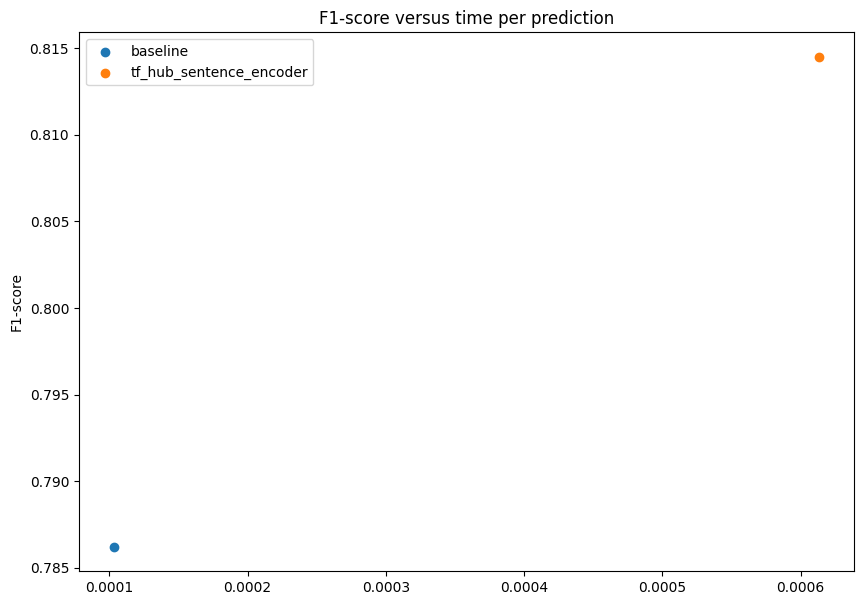

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(baseline_time_per_pred, baseline_results["f1"], label="baseline")
plt.scatter(model_6_time_per_pred, model_6_pretrained_results["f1"], label="tf_hub_sentence_encoder")
plt.legend()
plt.title("F1-score versus time per prediction")
plt.ylabel("F1-score")